In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import plotly.express as px

- Complaints from 3 jan 2020 to 31 dez 2025
- Violations from 3 jan 2020 to 31 dez 2025
- All 3 datasets with zip code and district

## 1. Income Areas

In [20]:
df_income=pd.read_csv("data/nyc_zipcode_income.csv")
print(df_income.isna().sum())
df_income = df_income.dropna()
df_income.head()

location            0
median_income       0
margin_of_error     0
zipcode             0
borough             0
council_district    9
dtype: int64


,location,median_income,margin_of_error,zipcode,borough,council_district
0,ZCTA5 10282,250001,-333333333,10282,Manhattan,1.0
1,ZCTA5 10004,250001,-333333333,10004,Manhattan,1.0
2,ZCTA5 10007,250001,-333333333,10007,Manhattan,1.0
3,ZCTA5 10279,250001,-333333333,10279,Manhattan,1.0
5,ZCTA5 10069,233636,52737,10069,Manhattan,6.0


count       183.000000
mean      97739.191257
std       45486.398931
min       24086.000000
25%       67825.500000
50%       88838.000000
75%      115729.000000
max      250001.000000
Name: median_income, dtype: float64


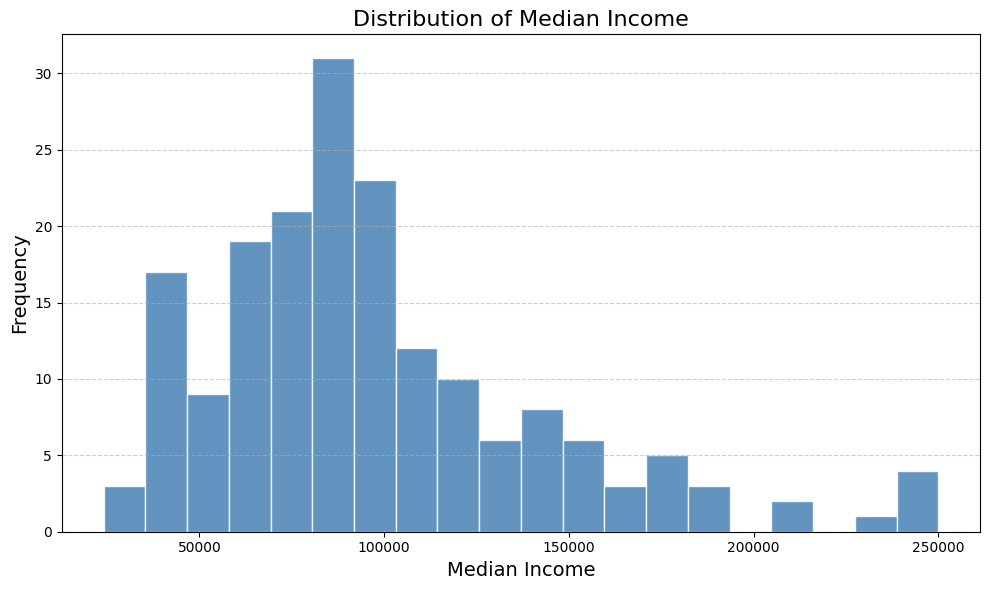

In [21]:
median_income=df_income["median_income"]
print(median_income.describe())


median_income = np.array(median_income)

plt.figure(figsize=(10, 6))
plt.hist(
    median_income,
    bins=20,
    color="steelblue",
    edgecolor="white",
    alpha=0.85
)

plt.title("Distribution of Median Income", fontsize=16)
plt.xlabel("Median Income", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

# Optional: add gridlines for readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
city_median = df_income["median_income"].median()

# income thats 0.8 of median is considered low
low_thr = 0.8 * city_median
mid_thr = 1.0 * city_median
high_thr = 1.2 * city_median

bins = [0, low_thr, mid_thr, high_thr, float("inf")]
labels = ["Low", "Low-Middle", "Middle-High", "High"]

df_income["income_cat"] = pd.cut(
    df_income["median_income"],
    bins=bins,
    labels=labels,
    right=False
)

df_income.head()

In [ ]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

df_income["zipcode"] = df_income["zipcode"].astype(str)
colors = px.colors.sequential.Blues[2:10]   # skip the very lightest ones
color_map = {
    "Low": colors[0],
    "Low-Middle": colors[2],
    "Middle-High": colors[4],
    "High": colors[6]}

fig = px.choropleth_mapbox(
    df_income,
    geojson=zip_geo,
    locations="zipcode",
    color="income_cat",
    color_discrete_map=color_map,
    mapbox_style="carto-positron",
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zipcode": True,
        "median_income": ":,",
        "income_cat": True
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
    legend_title_text="Income Category"
)

fig.write_html("data/visualizations/nyc_income_map.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_10056\3306808694.py:16: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
